In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data

import time
import numpy as np
import gc
import sys
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
# from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
from getFeatures_molecule import save_smiles_dicts, get_smiles_dicts, get_smiles_array



In [2]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import f1_score

In [ ]:
from rdkit import Chem
from rdkit.Chem import QED
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from IPython.display import SVG, display
import seaborn as sns; sns.set(color_codes=True)
from config import cfg

number of all smiles:  2050
not successfully processed smiles:  O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3
not successfully processed smiles:  c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC


[10:26:01] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] Explicit valence for atom # 6 N, 4, is greater than permitted
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01] WARNING: not removing hydrogen atom without neighbors
[10:26:01

not successfully processed smiles:  Cc1nc(sc1)\[NH]=C(\N)N
not successfully processed smiles:  s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N
not successfully processed smiles:  c1c(c(ncc1)CSCCN\C(=[NH]\C#N)NCC)Br
not successfully processed smiles:  n1c(csc1\[NH]=C(\N)N)c1ccccc1
not successfully processed smiles:  n1c(csc1\[NH]=C(\N)N)c1cccc(c1)N
not successfully processed smiles:  n1c(csc1\[NH]=C(\N)N)c1cccc(c1)NC(C)=O
not successfully processed smiles:  n1c(csc1\[NH]=C(\N)N)c1cccc(c1)N\C(NC)=[NH]\C#N
not successfully processed smiles:  s1cc(nc1\[NH]=C(\N)N)C
not successfully processed smiles:  c1(cc(N\C(=[NH]\c2cccc(c2)CC)C)ccc1)CC


[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not removing hydrogen atom without neighbors
[10:26:02] WARNING: not r

remained_smiles:  2039
number of successfully processed smiles:  2039
number of successfully processed smiles:  2039
canonical_smiles_list:  2039
new_smilesList:  2039
normal_2_standard:  2039


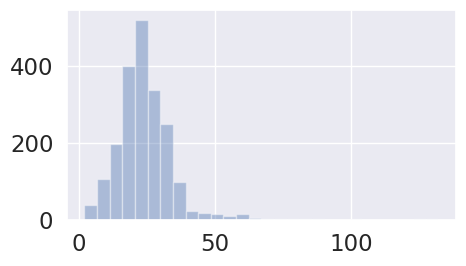

In [5]:
task_name = cfg.task_name
tasks = cfg.tasks###哪些标签
raw_filename = cfg.data_raw_filename###数据存放地址
feature_filename = raw_filename.replace('.csv','.pickle')####
filename = raw_filename.replace('.csv','')
prefix_filename = raw_filename.split('/')[-1].replace('.csv','')
smiles_tasks_df = pd.read_csv(raw_filename)
smilesList = smiles_tasks_df.smiles.values
print("number of all smiles: ",len(smilesList))
new_smilesList = []
atom_num_dist = []
remained_smiles = []
canonical_smiles_list = []
normal_2_standard = {}

for smiles in smilesList:
    try:        
        mol = Chem.MolFromSmiles(smiles)
        atom_num_dist.append(len(mol.GetAtoms()))
        remained_smiles.append(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
        new_smilesList.append(smiles)
        normal_2_standard[smiles] = Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True)
    except:
        print("not successfully processed smiles: ", smiles)
        pass
print("remained_smiles: ",len(remained_smiles))
print("number of successfully processed smiles: ", len(remained_smiles))
print("number of successfully processed smiles: ", len(remained_smiles))
print("canonical_smiles_list: ",len(canonical_smiles_list))
print("new_smilesList: ",len(new_smilesList))
print("normal_2_standard: ",len(normal_2_standard))


plt.figure(figsize=(5, 3))
sns.set(font_scale=1.5)
ax = sns.distplot(atom_num_dist, bins=28, kde=False)
plt.tight_layout()
# plt.savefig("atom_num_dist_"+prefix_filename+".png",dpi=200)
plt.show()
plt.close()


In [ ]:
from collections import defaultdict

def create_value_to_keys_dict(original_dict):
    value_to_keys = defaultdict(list)
    
    for key, value in original_dict.items():
        value_to_keys[value].append(key)
    result = {value: keys for value, keys in value_to_keys.items() if len(keys) > 1}
    
    return result

In [13]:
repeat_smiles_dict= create_value_to_keys_dict(normal_2_standard)

In [17]:
count_ = 0
anomaly_keys = []
anomaly_values = []
repeat_normal_smiles = []

for keys,values_list in repeat_smiles_dict.items():
    count_ += 1
    value2bbbp = []
    
    for ii in values_list:
        # print(ii)
        value2bbbp.append(smiles_tasks_df.loc[smiles_tasks_df['smiles'] == ii, 'BBBP'].values[0])
    
    if len(set(value2bbbp)) > 1:
        anomaly_keys.append(keys)
        anomaly_values.extend(values_list)
    
    if len(set(value2bbbp)) == 1:
        repeat_normal_smiles.extend(values_list[1:])
    
    print(value2bbbp)
    print(count_)
    print(keys)

[1, 1]
1
CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1
[1, 1]
2
CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23
[1, 1]
3
CC(=O)NCCCOc1cccc(CN2CCCCC2)c1
[1, 1]
4
ClCCl
[1, 1]
5
CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c1ccccc1
[1, 0]
6
CN(C)C(=O)C(CCN1CCC(O)(c2ccc(Cl)cc2)CC1)(c1ccccc1)c1ccccc1
[0, 0]
7
CN(C)Cc1ccc(CSCCNc2nc(=O)c(Cc3ccc4ccccc4c3)c[nH]2)o1
[1, 1]
8
FC(F)(F)c1ccc(N2CCNCC2)nc1Cl
[1, 1]
9
O=C(NCCCOc1cccc(CN2CCCCC2)c1)c1ccccc1
[1, 1]
10
CN1Cc2c(C(=O)OC(C)(C)C)ncn2-c2ccsc2C1=O
[1, 1]
11
CNCCCN1c2ccccc2Sc2ccc(Cl)cc21
[1, 1, 1]
12
CN(C)CCc1ccccn1
[1, 1]
13
O=C1CCCN1CCCCN1CCN(c2cc(C(F)(F)F)ccn2)CC1
[1, 1]
14
CCc1ccccc1
[1, 1]
15
CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1
[1, 1]
16
NCCCN1c2ccccc2Sc2ccc(Cl)cc21
[1, 1, 1]
17
CNCCc1ccccn1
[1, 1]
18
c1cc(CN2CCCCC2)cc(OCCCNc2nccs2)c1
[0, 0]
19
CN1Cc2c(-c3noc(C(C)(C)O)n3)ncn2-c2cccc(Cl)c2C1=O
[1, 1]
20
NC(=O)N1c2ccccc2C2OC2c2ccccc21
[1, 1]
21
CCCN(CCC)CCc1ccc(O)c2c1CC(=O)N2
[1, 1]
22
c1cc(CN2CCCCC2)cc(OCCCNc2nc3ccccc3o2)c1
[0, 0, 0]
23
NCCc1cn2ccccc2n1
[1

In [20]:
def remove_elements(large_list, small_list):
    # 将小列表转换为集合，提高查找效率
    remove_set = set(small_list)
    
    # 使用列表推导式生成新列表
    return [item for item in large_list if item not in remove_set]

In [21]:
new_smilesList = remove_elements(new_smilesList,anomaly_values)###这个肯定要去掉的
# new_smilesList = remove_elements(new_smilesList,repeat_normal_smiles)###这个去不去掉，随机划分不用去，scffold还是去掉；

In [ ]:
new_smilesList = [smiles for smiles in new_smilesList if len(Chem.MolFromSmiles(smiles).GetAtoms())<101]
# len(new_smilesList)

[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not removing hydrogen atom without neighbors
[10:26:22] WARNING: not r

2016

In [24]:
smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["smiles"].isin(new_smilesList)]

print(smiles_tasks_df)


      BBBP                                             smiles
0        1                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12
1        1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2        1  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3        1                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4        1  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...
...    ...                                                ...
2045     1    C1=C(Cl)C(=C(C2=C1NC(=O)C(N2)=O)[N+](=O)[O-])Cl
2046     1  [C@H]3([N]2C1=C(C(=NC=N1)N)N=C2)[C@@H]([C@@H](...
2047     1  [O+]1=N[N](C=C1[N-]C(NC2=CC=CC=C2)=O)C(CC3=CC=...
2048     1  C1=C(OC)C(=CC2=C1C(=[N+](C(=C2CC)C)[NH-])C3=CC...
2049     1  [N+](=NCC(=O)N[C@@H]([C@H](O)C1=CC=C([N+]([O-]...

[2016 rows x 2 columns]


In [25]:
normal_smilesList = smiles_tasks_df.smiles.values
canonical_smiles_new_list = []
for smile in normal_smilesList:
    canonical_smiles_new_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smile), isomericSmiles=True))
# smiles_tasks_df['cano_smiles'] =canonical_smiles_new_list
smiles_tasks_df.loc[:, 'cano_smiles'] = canonical_smiles_new_list

[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not removing hydrogen atom without neighbors
[10:26:23] WARNING: not r

In [ ]:
feature_dicts = save_smiles_dicts(canonical_smiles_new_list,filename)######attentivefp，传的是普通smiles；

remained_df = smiles_tasks_df[smiles_tasks_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]

remained_df = remained_df.reset_index(drop=True)
assert remained_df['cano_smiles'][999]==Chem.MolToSmiles(Chem.MolFromSmiles(remained_df['smiles'][999]), isomericSmiles=True)

df_filename = filename + '_remained_df'
pickle.dump(remained_df,open(df_filename+'.pickle',"wb"))

[10:26:24] WARNING: not removing hydrogen atom without neighbors
[10:26:24] WARNING: not removing hydrogen atom without neighbors
[10:26:25] WARNING: not removing hydrogen atom without neighbors
[10:26:25] WARNING: not removing hydrogen atom without neighbors
[10:26:25] WARNING: not removing hydrogen atom without neighbors
[10:26:25] WARNING: not removing hydrogen atom without neighbors
[10:26:25] WARNING: not removing hydrogen atom without neighbors
[10:26:25] WARNING: not removing hydrogen atom without neighbors
[10:26:26] WARNING: not removing hydrogen atom without neighbors
[10:26:26] WARNING: not removing hydrogen atom without neighbors
[10:26:26] WARNING: not removing hydrogen atom without neighbors
[10:26:26] WARNING: not removing hydrogen atom without neighbors
[10:26:26] WARNING: not removing hydrogen atom without neighbors
[10:26:26] WARNING: not removing hydrogen atom without neighbors
[10:26:27] WARNING: not removing hydrogen atom without neighbors
[10:26:27] WARNING: not r

feature dicts file saved as ./data/BBBP.pickle
